In [ ]:
import os
import numpy as np
import pandas as pd
import pymysql
from presto_cli import presto_client
from presto_cli_v2 import presto_client_v2 as presto
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_rows', 1000)
pd.set_option('display.max_columns', 1000)
%load_ext autoreload
%autoreload 2
import datetime
from data import *
from getData import *
import json
import datetime

from collections import Counter
import matplotlib.pyplot as plt
# 设置全局字体为黑体
plt.rcParams['font.sans-serif'] = ['SimHei']
# 解决负号显示问题
plt.rcParams['axes.unicode_minus'] = False


In [ ]:
def get_route():
    sql = """
        SELECT t1.*
        FROM (
            -- 第一步：小表先计算，只查需要的 apply_id（极小数据量）
            SELECT DISTINCT apply_id
            FROM guazi_dw_dw.dw_event_loan_order_ymd
            WHERE dt = '2026-03-25'
              AND first_submit_credit_audit_time >= '2026-02-01'
              AND first_submit_credit_audit_time < '2026-03-01'
              AND fin_type = 10
              AND is_ecommerce = 1
        ) t0
        -- 第二步：直接 JOIN 大表（比 IN 快 10 倍以上）
        INNER JOIN guazi_dw_dwd.dim_qf_result_data_store_ymd t1
        ON t0.apply_id = t1.apply_id
        -- 第三步：大表分区 + 过滤条件提前写
        WHERE t1.dt = '2026-03-25'
        AND t1.table_type = 'big_table'
    """
    cursor = presto.connect_presto(sql, username='zhangjuhui')
    df = cursor.querySQL()
    return df
df = get_route()
print(df.shape)
df.to_csv(r'/Users/jhzhang/Desktop/guazi/finsrc/data/src/route_details2602.csv', index=False)

In [ ]:
import os
os.makedirs('/Users/jhzhang/Desktop/guazi/finsrc/data/dst', exist_ok=True)

files = os.listdir(r'data/src')
files = [file for file in files if file.endswith('.csv')]
print(files)
for file in files:
    rows_list = []
    src_path = os.path.join(r'data/src', file)
    print(src_path)
    df = pd.read_csv(src_path, encoding='utf-8')
    bodys = df['body'].values
    row_keys = df['row_key'].values
    for idx, (body, rk) in enumerate(zip(bodys, row_keys)):
        if idx % 50000 == 0:
            print(f"受进度: {idx}/{len(bodys)}")
        tmp = {'row_key': rk}
        bjson = json.loads(body)
        for k, v in bjson.items():
            if k != 'data':
                tmp[k] = v
            else:
                data_dict = bjson['data']
                for kk, vv in data_dict.items():
                    if kk != 'data':
                        tmp[kk] = vv
                    else:
                        inner_js = json.loads(data_dict['data'])
                        tmp.update(inner_js)
        rows_list.append(tmp)
    df_detail = pd.DataFrame(rows_list)
    dst_path = os.path.join(r'data/dst', file)
    df_detail.to_csv(dst_path, index=False)

In [ ]:
def get_ll():
    sql = '''select * from qf_dwb.dwb_qfjr__jr_compass_priority_day t
             WHERE progress =2 and deprived=0
               and reason not in('CS00002014','CS00002015','CS00002005')
               and dt = '2026-03-25' '''
    cursor = presto.connect_presto(sql, username='jinxiaosong')
    df = cursor.querySQL()
    return df

In [ ]:
df_ll = get_ll()
df_ll.shape

In [ ]:
df_ll.head()

In [ ]:
def get_rule_level():
    sql = '''
            SELECT *
            FROM
              (
                SELECT *
                FROM
                  (
                  SELECT
                      identity_key,
                      request_mon,
                      guazi_risk_level_2
                  FROM
                    (
                      SELECT
                        identity_key,
                        substr(date_format(from_unixtime((request_time / 1000), 'Asia/Shanghai'), '%Y-%m-%d'), 1, 7) request_mon,
                        CAST(json_extract_scalar(rule_result, '$.guazi_risk_level_2') AS DOUBLE) guazi_risk_level_2,
                        row_number() OVER (PARTITION BY identity_key ORDER BY request_time ASC) rn
                      FROM
                        gzlc_real.fact_rule_engine_result_log
                      WHERE dt >= '2024-07-31'
                        AND ruleset_key = 'guazi_risk_level.dmn'
                        AND identity_key <> ''
                        AND work_flow = 'indep-pre'
                      )
                  WHERE rn = 1
                  )
                UNION (
                  SELECT
                      identity_key,
                      substr(date_format(parse_datetime(request_time, 'yyyy/M/d'), '%Y-%m-%d'), 1, 7) request_mon,
                      guazi_risk_level_2
                  FROM
                    finance_model.jr_risk_guazi_risk_level_2_day_his
                  WHERE NOT identity_key IN (
                      SELECT
                        identity_key
                      FROM gzlc_real.fact_rule_engine_result_log
                      WHERE dt >= '2024-07-31'
                        AND ruleset_key = 'guazi_risk_level.dmn'
                        AND work_flow = 'indep-pre'
                  )
                )
              )
    '''
    cursor = presto.connect_presto(sql, username='jinxiaosong')
    df = cursor.querySQL()
    return df


In [ ]:
df_rule_level = get_rule_level()
df_rule_level.columns = ['apply_id', 'request_mon', 'guazi_risk_level_2']
smry = get_data_summary(df_rule_level)
smry

In [ ]:
lvl_dict = {2:"C",3:"C",4:"C",1:"B",5:"D",6:"B",7:"B",8:"A",9:"B"}
df_rule_level['rule_level'] = df_rule_level['guazi_risk_level_2'].map(lvl_dict)
df_rule_level.drop(['request_mon', 'guazi_risk_level_2'], axis=1, inplace=True)
df_rule_level.columns = ['apply_id', 'rule_level']
df_rule_level.head()

In [ ]:
df_rule_level.to_csv('rule_level.csv', index=False)

In [ ]:
df_rule_level.head()

In [ ]:
def get_loan():
    sql = """
	SELECT
	t.apply_id,
    t.total_loan_amount
	,if(t.give_time != 0, from_unixtime(t.give_time), null) as "give_time"
    FROM
     qf_dwb.dwb_qfjr__finance_finance_loan_order_day t
	WHERE dt = '2026-03-25'
    and give_time is not null
    """
    cursor = presto.connect_presto(sql, username='zhangjuhui')
    df = cursor.querySQL()
    return df
df_loan = get_loan()

In [ ]:
df_loan = df_loan[df_loan['give_time'].isnull()==False]
smry = get_data_summary(df=df_loan)
smry

In [ ]:
df_loan.to_csv(r'data/loan.csv', index=False)
df_loan = pd.read_csv(r'data/loan.csv')

In [ ]:
#df_detail = df_detail.sort_values(by=['apply_id', 'time_stamp'])

In [ ]:
#df_detail.head(200)

In [ ]:
def get_dw_event_loan_order_ymd():
    sql = '''
   SELECT apply_id,
      down_payment_rate,
      loan_periods,
      give_time,
      product_bank_name,
      car_loan_amount
   FROM
     guazi_dw_dw.dw_event_loan_order_ymd
   WHERE dt = '2026-03-25'
     AND first_submit_credit_audit_time >= '2025-05-01'
     AND fin_type = 10
     AND is_ecommerce = 1
    '''
    cursor = presto.connect_presto(sql, username='jinxiaosong')
    df = cursor.querySQL()
    return df

In [ ]:
df = get_dw_event_loan_order_ymd()
smry = get_data_summary(df=df)
smry

In [ ]:
files = os.listdir(r'data/dst')
files = [file for file in files if file.endswith('csv')]
for file in files:
    src_path = os.path.join(r'data/dst', file)
    df_detail_tmp = pd.read_csv(src_path)
    break

In [ ]:
df_detail_tmp.head()

In [ ]:
smry = get_data_summary(df=df_detail[['row_key', 'apply_id', 'request_id', 'source_code', 'version', 'prioity', 'current_route_reason', 'current_route_down_payment_rate', 'current_route_duration_number']])
smry

In [ ]:
#df_detail = pd.read_csv(r'data/df_detail.csv')
#smry = get_data_summary(df=df_detail[['row_key', 'apply_id', 'request_id', 'source_code', 'version', 'prioity', 'current_route_reason', 'current_route_down_payment_rate', 'current_route_duration_number']])
#smry

In [ ]:
df.head(2)

In [ ]:
df_detail.head(2)

In [ ]:
df = df.drop(['body', 'time_stamp', 'apply_id', 'request_id', 'table_type', 'funder_id', 'batch_id'], axis=1)
df = df.merge(df_detail, on='row_key', how='left')
df.head()

In [ ]:
smry = get_data_summary(df=df[['row_key', 'id', 'apply_id', 'request_id', 'source_code', 'version', 'prioity', 'current_route_reason', 'current_route_down_payment_rate', 'current_route_duration_number']])
smry

In [ ]:
df['time_stamp_x'] = df['time_stamp'].apply(lambda x: datetime.datetime.utcfromtimestamp(x))
df[['time_stamp', 'time_stamp_x']].head()

In [ ]:
map_progress = {0:"队列中", 1:"审核中", 2:"通过", 3:"拒绝", 4:"待补件", 5:"失败", 6:"取消", 7:"跳过", 8:"跳过拒绝", 9:"人工审核失败"}

In [ ]:
def get_bank_map():
    sql = '''
   SELECT
      distinct product_bank_id,
      product_bank_name
   FROM
     guazi_dw_dw.dw_event_loan_order_ymd
   WHERE dt = '2026-03-24'
    '''
    cursor = presto.connect_presto(sql, username='jinxiaosong')
    df = cursor.querySQL()
    return df
df_bank_map = get_bank_map()
df_bank_map = df_bank_map[df_bank_map['product_bank_id'].isnull()==False]
df_bank_map['product_bank_id'] = df_bank_map['product_bank_id'].astype(int)

In [ ]:
df_bank_map

In [ ]:
df['time_stamp'] = df['time_stamp'].apply(lambda x: datetime.datetime.utcfromtimestamp(x))
df['current_route_progress'] = df['current_route_progress'].apply(lambda x: map_progress[x])
df['current_route_funder_id'] = df['current_route_funder_id'].astype(int)
df = df[df['current_route_funder_id'].apply(lambda x: x in [39, 97, 8, 0, 119, 142, 134, 141])]
df = df.merge(df_bank_map, left_on='current_route_funder_id', right_on='product_bank_id', how='left')
df = df.sort_values(by=['apply_id', 'version', 'prioity', 'time_stamp'], ascending=[False, False, False, False])
df[['apply_id', 'version', 'prioity', 'time_stamp', 'current_route_progress']].head(100)

In [ ]:
name_map = {'兴邦金租': '兴邦金租', '大众租赁瓜子版': '大众租赁', '大众金融': '大众金融', '大众金融LE版': '大众金融', '大众金融线上版': '大众金融', '新生中信': '新生中信', '瓜子': '瓜子', '联众国银': '联众国银'}
df['product_bank_name'] = df['product_bank_name'].apply(lambda x: name_map[x])

In [ ]:
df = df.sort_values(by=['apply_id', 'version', 'prioity', 'time_stamp'], ascending=[False, False, False, False])

In [ ]:
get_freq(df, ['prioity'])

In [ ]:
df_tmp = df[df['prioity']==5]
df_tmp.head(20)

In [ ]:
df[df['apply_id']=='390be9f0456eb4a16af67d0a2f99bbfa'][['apply_id', 'version', 'current_route_progress', 'prioity', 'time_stamp', 'product_bank_name', 'created_at', 'updated_at', 'source_code']]

In [ ]:
df[['apply_id', 'version', 'current_route_progress', 'prioity', 'time_stamp', 'product_bank_name', 'created_at', 'updated_at', 'source_code']].head(100)

In [ ]:
df = df.sort_values(by=['apply_id', 'prioity', 'time_stamp'], ascending=[False, False, False])
df = df.drop_duplicates(subset=['apply_id', 'prioity'], keep='first')
smry = get_data_summary(df=df[['apply_id', 'version', 'current_route_progress', 'prioity', 'time_stamp', 'product_bank_name', 'created_at', 'updated_at', 'source_code']])
smry

In [ ]:
df[df['apply_id']=='390be9f0456eb4a16af67d0a2f99bbfa'][['apply_id', 'version', 'current_route_progress', 'prioity', 'time_stamp', 'product_bank_name', 'created_at', 'updated_at', 'source_code']]

In [ ]:
df_loan['give_time'] = '放款'
df = df.merge(df_loan, on='apply_id', how='left')
df['give_time'] = df['give_time'].fillna('')
df['current_route_progress'] = df['current_route_progress'] + df['give_time']

In [ ]:
df[['apply_id', 'version', 'current_route_progress', 'prioity', 'time_stamp', 'product_bank_name', 'created_at', 'updated_at', 'source_code']].head(100)

In [ ]:
get_freq(df, ['version'])

In [ ]:
def get_nmp(x):
    nmap = {'审核中放款':'审核中', '待补件放款':'待补件', '拒绝放款':'拒绝', '跳过放款':'跳过', '通过':'通过未放款', '通过放款':'通过且放款'}
    if x in nmap.keys():
        return nmap[x]
    else:
        return x
df['current_route_progress'] = df['current_route_progress'].apply(lambda x: get_nmp(x))

In [ ]:
df = df.sort_values(by=['apply_id', 'time_stamp'], ascending=[False, False])
df['funderid'] = df.groupby(['apply_id']).cumcount() + 1

In [ ]:
df[['apply_id', 'funderid', 'version', 'current_route_progress', 'prioity', 'time_stamp', 'product_bank_name', 'created_at', 'updated_at', 'source_code']].head(100)

In [ ]:
get_freq(df, ['funderid'])

In [ ]:
df_1 = df[df['funderid'] == 1]
matrix = pd.crosstab(df_1['product_bank_name'], df_1['current_route_progress'], normalize=True)
matrix['Row_Sum'] = matrix.sum(axis=1)
matrix.loc['Col_Sum'] = matrix.sum(axis=0)
matrix

In [ ]:
get_freq(df_1, ['current_route_progress'])

In [ ]:
df_2 = df[df['funderid'] == 2]
matrix = pd.crosstab(df_2['product_bank_name'], df_2['current_route_progress'], normalize=True)
matrix['Row_Sum'] = matrix.sum(axis=1)
matrix.loc['Col_Sum'] = matrix.sum(axis=0)
matrix

In [ ]:
get_freq(df_2, ['current_route_progress'])

In [ ]:
df_3 = df[df['funderid'] == 3]
matrix = pd.crosstab(df_3['product_bank_name'], df_3['current_route_progress'], normalize=True)
matrix['Row_Sum'] = matrix.sum(axis=1)
matrix.loc['Col_Sum'] = matrix.sum(axis=0)
matrix

In [ ]:
df.head(100)

In [ ]:
df_1 = df[df['version']==1]
get_freq(df_1, ['current_route_progress'])

In [ ]:
get_freq(df, ['version'])

In [ ]:
df = df.sort_values(by=['apply_id', 'version', 'prioity', 'time_stamp'], ascending=[False, False, False, False])
df[df['apply_id']=='fff6a2b07b266ec5daed2f0cf0971742'][['apply_id', 'version', 'prioity', 'time_stamp', 'current_route_progress', 'current_route_funder_id']].head(100)

In [ ]:
df[df['apply_id']=='fff6a2b07b266ec5daed2f0cf0971742']

In [ ]:
bjson['data']['data']

In [ ]:
for k, v in bjson['data']['data'].items():
    print(k, v)

In [ ]:
month_start = ['2025-01-01', '2025-02-01', '2025-03-01', '2025-04-01', '2025-05-01']
month_end = ['2025-01-31', '2025-02-28', '2025-03-31', '2025-04-30', '2025-05-20']

In [ ]:
for i in range(len(month_start)):
    start = month_start[i]
    end = month_end[i]
    print(start, end)
    df = get_route(start, end)
    df.to_csv(r'/Users/jhzhang/Desktop/guazi/finsrc/data/route_{0}_{1}.csv'.format(start, end), index=False)
    print(df.shape)

In [ ]:
dfa = get_rule_level('', '', )
print(len(dfa))
smry = get_data_summary(df=dfa)
smry

In [ ]:
smry = get_data_summary(df_A[['apply_id', 'current_route_latest_audit_timestamp', 'rank']])
smry

In [ ]:
sql = """
  select t.apply_id AS "apply_id"
  ,t.funder_id AS "rule_funder_id"
  ,from_unixtime(cast(json_extract(json_extract_scalar(t.body,'$.data.data'), '$.time_stamp')as integer)) AS "count_time"
  ,json_extract_scalar(json_extract_scalar(t.body,'$.data.data'), '$.category') AS "category"
  ,json_extract_scalar(json_extract_scalar(t.body,'$.data.data'), '$.reason') AS "reason"
  ,json_extract_scalar(json_extract_scalar(t.body,'$.data.data'), '$.c2c_priority') AS "city_priority"
  ,json_extract_scalar(json_extract_scalar(t.body,'$.data.data'), '$.current_funder_id') AS "current_funder_id"
  ,cast(json_extract(json_extract_scalar(t.body,'$.data.data'), '$.current_funder_progress') as integer) AS "progress"
  ,cast(json_extract(json_extract_scalar(t.body,'$.data.data'), '$.current_downpayment_rate') as integer) AS "current_downpayment_rate"
  ,cast(json_extract(json_extract_scalar(t.body,'$.data.data'), '$.current_duration_number') as integer) AS "current_duration_number"
  ,cast(json_extract(json_extract_scalar(t.body,'$.data.data'), '$.current_c2c_type') as integer) AS "current_c2c_type"
  ,row_number() over(partition by t.apply_id, t.funder_id order by t.time_stamp desc) rank
from guazi_dw_dwd.dim_qf_result_data_store_ymd t
where t.dt = '2025-05-20' and t.table_type = 'funder_distribute' and t.funder_id = 8
"""
df_B = pd.read_sql_query(sql=sql,con=cursor)
df_B.head()

In [ ]:
sql ="""
select t.city_id
  ,t.short_name
  ,t.province_short_name
from guazi_dw_dwd.dim_com_city_ymd t
where dt = '2025-05-20'
"""
df_C = pd.read_sql_query(sql=sql,con=cursor)
df_C.head()

In [ ]:
sql = """
select * from
  (values
(0, '队列中'),
(1, '路由中'),
(2, '资方审核通过'),
(3, '资方审核拒绝'),
(4, '中断/补材料'),
(7, '跳过')) as t(progress,progress_name)
"""
df_D = pd.read_sql_query(sql=sql,con=cursor)
df_D

In [ ]:
df_D

In [ ]:
sql = """
select t.apply_id, t.created_at, row_number() over(partition by t.apply_id order by t.created_at desc) rank
from qf_dwb.dwb_qfjr__jr_compass_audit_day t
where t.dt = '2025-05-20'
and t.created_at >= '2025-04-01'
"""
df_E = pd.read_sql_query(sql=sql,con=cursor)
df_E.head()

In [ ]:
sql = """
select cast(org_code as integer) org_code, org_name
from qf_dwb.dwb_qfjr__jr_d_product_center_t_orgs_day
where dt = '2025-05-20'
"""
df_F = pd.read_sql_query(sql=sql,con=cursor)
df_F.head()


In [ ]:
sql = """
SELECT
    clue_id
    ,fuel_type
    ,auto_type
    ,minor_category_name
    ,tag_name
	 ,CASE WHEN fuel_type = 11 THEN '压缩天然气(CNG)' WHEN fuel_type = 12 THEN '增程式电动' WHEN fuel_type = 13 THEN '插电式混动' WHEN fuel_type = 14 THEN '柴油' WHEN fuel_type = 15 THEN '汽油' WHEN fuel_type = 16 THEN '汽油/压缩天然气(CNG)' WHEN fuel_type = 17 THEN '汽油/液化石油气(LPG)' WHEN fuel_type = 18 THEN '油电混合' WHEN fuel_type = 19 THEN '液化石油气(LPG)' WHEN fuel_type = 20 THEN '纯电动' WHEN fuel_type = 21 THEN '汽油+48V轻混系统' WHEN fuel_type = 22 THEN '氢燃料电池'WHEN fuel_type = 26 THEN '汽油+90V轻混系统' WHEN fuel_type = 27 THEN '汽油+24V轻混系统'WHEN fuel_type = 29 THEN '汽油电驱' WHEN fuel_type = 23 THEN '油改气' ELSE CAST(fuel_type AS VARCHAR) END "fuel_type_name"
FROM guazi_dw_dwd.dim_com_car_source_ymd
WHERE dt = '2025-05-20'
"""
df_G = pd.read_sql_query(sql=sql,con=cursor)
df_G.head()

In [ ]:
df_G.head()


In [ ]:
sql = """
	SELECT
	t.order_id
	,t.apply_id
	,t.status_code
	FROM
	qf_dwb.dwb_qfjr__finance_vehicle_finance_loan_order_state_day t
	WHERE dt = '2025-05-20'
"""
df_H = pd.read_sql_query(sql=sql,con=cursor)
df_H.head()

In [ ]:
sql = """
	SELECT
	t.order_id
	,t.apply_id
	,t.status_code
	FROM
	qf_dwb.dwb_qfjr__finance_vehicle_finance_loan_order_state_day t
	WHERE dt = '2025-05-20'
"""
df_I = pd.read_sql_query(sql=sql,con=cursor)
df_I.head()

In [ ]:
,g as (

)
,h as (
	SELECT
	t.order_id
	,t.apply_id
	,t.status_code
	FROM
	qf_dwb.dwb_qfjr__finance_vehicle_finance_loan_order_state_day t
	WHERE dt = '2025-05-20'
)

,i as (
	SELECT
	t.apply_id
	,if(t.give_time != 0, from_unixtime(t.give_time), null) as "give_time"
FROM
  qf_dwb.dwb_qfjr__finance_finance_loan_order_day t
	WHERE dt = '2025-05-20'

In [ ]:
sql =
"""
WITH a AS (
  SELECT * FROM (
    SELECT
    t.apply_id AS "apply_id"
    ,from_unixtime(cast(json_extract(json_extract_scalar(t.body,'$.data.data'), '$.current_route_latest_audit_timestamp')as integer), 'Asia/Shanghai') AS "current_route_latest_audit_timestamp"
	 ,cast(JSON_EXTRACT(JSON_EXTRACT_SCALAR(t.body, '$.data.data'), '$.car_clue_id') AS Integer) AS "car_clue_id"
    ,cast(JSON_EXTRACT(JSON_EXTRACT_SCALAR(t.body, '$.data.data'), '$.chd_user_level') AS Integer) AS "chd_user_level"
    ,cast(JSON_EXTRACT(JSON_EXTRACT_SCALAR(t.body, '$.data.data'), '$.euler_user_level') AS Integer) AS "euler_level"
	,IF(cast(json_extract_scalar(json_extract_scalar(t.body, '$.data.data'), '$.operation') as integer) =2, TRUE, FALSE) AS "is_taxi"
	,IF(json_extract_scalar(json_extract_scalar(t.body, '$.data.data'), '$.auto_type') is null,0,cast(json_extract_scalar(json_extract_scalar(t.body, '$.data.data'), '$.auto_type') as integer)) AS "auto_type"
	,IF(json_extract_scalar(json_extract_scalar(t.body, '$.data.data'), '$.operation') is null,0,cast(json_extract_scalar(json_extract_scalar(t.body, '$.data.data'), '$.operation') as integer)) AS "operation"

    ,cast(JSON_EXTRACT(JSON_EXTRACT_SCALAR(t.body, '$.data.data'), '$.current_migrate_city_id') AS Integer) AS "city_id"
    ,cast(JSON_EXTRACT(JSON_EXTRACT_SCALAR(t.body, '$.data.data'), '$.car_age') AS Integer) AS "car_age"
    ,cast(JSON_EXTRACT(JSON_EXTRACT_SCALAR(t.body, '$.data.data'), '$.car_price') AS Integer) AS "car_price"
	  ,cast(json_extract(json_extract_scalar(t.body, '$.data.data'), '$.car_source_tags') as ARRAY(integer)) as "car_source_tags"
	  ,arrays_overlap(cast(json_extract(json_extract_scalar(t.body, '$.data.data'), '$.car_source_tags') as ARRAY(integer)), ARRAY[1070]) as "new_car_pure"
	  ,arrays_overlap(cast(json_extract(json_extract_scalar(t.body, '$.data.data'), '$.car_source_tags') as ARRAY(integer)), ARRAY[1069]) as "new_car_tax"
	  ,arrays_overlap(cast(json_extract(json_extract_scalar(t.body, '$.data.data'), '$.car_source_tags') as ARRAY(integer)), ARRAY[49]) as "is_mortgage_car"

	  ,arrays_overlap(cast(json_extract(json_extract_scalar(t.body, '$.data.data'), '$.car_source_tags') as ARRAY(integer)), ARRAY[1009]) as "parallel_import_car"
	  ,arrays_overlap(cast(json_extract(json_extract_scalar(t.body, '$.data.data'), '$.car_source_tags') as ARRAY(integer)), ARRAY[1036]) as "chongqing_new_car"
	  ,arrays_overlap(cast(json_extract(json_extract_scalar(t.body, '$.data.data'), '$.car_source_tags') as ARRAY(integer)), ARRAY[1093]) as "return_buy_car"

    ,cast(json_extract(json_extract_scalar(t.body, '$.data.data'), '$.origin_intent_down_payment_rate') as integer) as "origin_down_payment_rate"
    ,cast(json_extract(json_extract_scalar(t.body, '$.data.data'), '$.origin_intent_duration_number') as integer)as "origin_duration_number"
    ,arrays_overlap(cast(json_extract(json_extract_scalar(t.body, '$.data.data'), '$.current_intent_product_tags') as ARRAY(VARCHAR)), ARRAY['unflex_rate_low']) as "is_low_rate_intent"
    ,cast(json_extract(json_extract_scalar(t.body, '$.data.data'), '$.current_intent_down_payment_rate') as integer) as "intent_down_payment_rate"
    ,cast(json_extract(json_extract_scalar(t.body, '$.data.data'), '$.current_intent_duration_number') as integer)as "intent_duration_number"
    ,cast(json_extract(json_extract_scalar(t.body, '$.data.data'), '$.current_intent_c2c_type') as integer)as "intent_c2c_type"
	  ,json_extract(json_extract_scalar(t.body, '$.data.data'), '$.risk_support_banks') as "risk_support_banks"
	  ,IF(json_size(json_extract_scalar(t.body, '$.data.data'), '$.risk_support_flex_rate_banks') > 0, TRUE,FALSE) as "risk_support_flex_rate_can"
	  ,json_extract(json_extract_scalar(t.body, '$.data.data'), '$.risk_support_flex_rate_banks') as "risk_support_flex_rate_banks"
	  ,cast(json_extract(json_extract_scalar(t.body, '$.data.data'), '$.rate_year') as varchar) as "rate_year"
	  ,json_extract(json_extract_scalar(t.body, '$.data.data'), '$.current_route_can_banks') as "current_route_can_banks"
	  ,IF(json_size(json_extract_scalar(t.body, '$.data.data'), '$.current_route_can_flex_rate_banks') > 0, TRUE,FALSE) as "current_route_can_flex_rate_can"
	  ,json_extract(json_extract_scalar(t.body, '$.data.data'), '$.current_route_can_flex_rate_banks') as "current_route_can_flex_rate_banks"
	  ,json_extract(json_extract_scalar(t.body, '$.data.data'), '$.pass_product_list') as "pass_product_list"
	  ,arrays_overlap(cast(json_extract(json_extract_scalar(t.body, '$.data.data'), '$.risk_support_banks') as ARRAY(integer)), ARRAY[39,97,8,0,119,142,134,141]) as "is_non_sp"
	  ,arrays_overlap(cast(json_extract(json_extract_scalar(t.body, '$.data.data'), '$.current_route_can_banks') as ARRAY(integer)), ARRAY[39,97,8,0,119,142,134,141]) as "route_is_non_sp"
	  ,json_extract(json_extract_scalar(t.body, '$.data.data'), '$.risk_tags') as "risk_tags"
	  ,cast(json_extract(json_extract_scalar(t.body, '$.data.data'), '$.current_route_non_sp_min_down_payment_rate') as integer) as "router_min_down_payment_rate"
	  ,cast(json_extract(json_extract_scalar(t.body, '$.data.data'), '$.current_route_non_sp_max_duration_number') as integer) as "router_max_duration_number"
	  ,CASE WHEN substr(t.time_stamp,1,10) < '2024-09-04' and cast(json_extract(json_extract_scalar(t.body, '$.data.data'), '$.is_plus_pre_route') as varchar) = 'true' then true
                              when substr(t.time_stamp,1,10) >= '2024-09-04' and cast(json_extract(json_extract_scalar(t.body, '$.data.data'), '$.is_biz_pre_route') as varchar) = 'true' then true
                              else false end AS is_pre_route
	  -- ,cast(array_min(regexp_extract_all(json_format(JSON_EXTRACT(JSON_EXTRACT_SCALAR(t.body, '$.data.data'), '$.pass_product_list')), '"down_payment_rate":(\d+).*?"funder_list":.*?\[.*?0.*?8.*?39.*?97.*?\]', 1)) as integer) AS "router_min_down_payment_rate"

	  ,json_array_contains(json_extract(json_extract_scalar(t.body, '$.data.data'), '$.risk_support_banks'), 39) as "risk_has_39"
	  ,json_array_contains(json_extract(json_extract_scalar(t.body, '$.data.data'), '$.risk_support_banks'), 8) as "risk_has_8"
	  ,json_array_contains(json_extract(json_extract_scalar(t.body, '$.data.data'), '$.risk_support_banks'), 97) as "risk_has_97"
	  ,json_array_contains(json_extract(json_extract_scalar(t.body, '$.data.data'), '$.risk_support_banks'), 129) as "risk_has_129"
	  ,json_array_contains(json_extract(json_extract_scalar(t.body, '$.data.data'), '$.risk_support_banks'), 119) as "risk_has_119"
	  ,json_array_contains(json_extract(json_extract_scalar(t.body, '$.data.data'), '$.risk_support_banks'), 128) as "risk_has_128"
	  ,json_array_contains(json_extract(json_extract_scalar(t.body, '$.data.data'), '$.risk_support_banks'), 0) as "risk_has_0"
	  ,json_array_contains(json_extract(json_extract_scalar(t.body, '$.data.data'), '$.risk_support_banks'), 120) as "risk_has_120"
	  ,json_array_contains(json_extract(json_extract_scalar(t.body, '$.data.data'), '$.risk_support_banks'), 134) as "risk_has_134"
	  ,json_array_contains(json_extract(json_extract_scalar(t.body, '$.data.data'), '$.risk_support_banks'), 135) as "risk_has_135"
	  ,json_array_contains(json_extract(json_extract_scalar(t.body, '$.data.data'), '$.risk_support_banks'), 141) as "risk_has_141"
	  ,json_array_contains(json_extract(json_extract_scalar(t.body, '$.data.data'), '$.risk_support_banks'), 142) as "risk_has_142"

	  ,json_array_contains(json_extract(json_extract_scalar(t.body, '$.data.data'), '$.current_route_banks'), 39) as "route_has_39"
	  ,json_array_contains(json_extract(json_extract_scalar(t.body, '$.data.data'), '$.current_route_banks'), 8) as "route_has_8"
	  ,json_array_contains(json_extract(json_extract_scalar(t.body, '$.data.data'), '$.current_route_banks'), 97) as "route_has_97"
	  ,json_array_contains(json_extract(json_extract_scalar(t.body, '$.data.data'), '$.current_route_banks'), 129) as "route_has_129"
	  ,json_array_contains(json_extract(json_extract_scalar(t.body, '$.data.data'), '$.current_route_banks'), 119) as "route_has_119"
	  ,json_array_contains(json_extract(json_extract_scalar(t.body, '$.data.data'), '$.current_route_banks'), 128) as "route_has_128"
	  ,json_array_contains(json_extract(json_extract_scalar(t.body, '$.data.data'), '$.current_route_banks'), 0) as "route_has_0"
	  ,json_array_contains(json_extract(json_extract_scalar(t.body, '$.data.data'), '$.current_route_banks'), 120) as "route_has_120"
	  ,json_array_contains(json_extract(json_extract_scalar(t.body, '$.data.data'), '$.current_route_banks'), 134) as "route_has_134"
	  ,json_array_contains(json_extract(json_extract_scalar(t.body, '$.data.data'), '$.current_route_banks'), 135) as "route_has_135"
	  ,json_array_contains(json_extract(json_extract_scalar(t.body, '$.data.data'), '$.current_route_banks'), 141) as "route_has_141"
	  ,json_array_contains(json_extract(json_extract_scalar(t.body, '$.data.data'), '$.current_route_banks'), 142) as "route_has_142"

	  ,cast(array_min(regexp_extract_all(json_format(JSON_EXTRACT(JSON_EXTRACT_SCALAR(t.body, '$.data.data'), '$.risk_bank_credit_map.8')), '("min_down_payment_rate":)([1-9]\d)(,")', 2)) as integer) * 100 AS "risk_down_payment_rate_8"
	  ,cast(array_min(regexp_extract_all(json_format(JSON_EXTRACT(JSON_EXTRACT_SCALAR(t.body, '$.data.data'), '$.risk_bank_credit_map.0')), '("min_down_payment_rate":)([1-9]\d)(,")', 2)) as integer) * 100 AS "risk_down_payment_rate_0"
	  ,cast(array_min(regexp_extract_all(json_format(JSON_EXTRACT(JSON_EXTRACT_SCALAR(t.body, '$.data.data'), '$.risk_bank_credit_map.97')), '("min_down_payment_rate":)([1-9]\d)(,")', 2)) as integer) * 100 AS "risk_down_payment_rate_97"
	  ,cast(array_min(regexp_extract_all(json_format(JSON_EXTRACT(JSON_EXTRACT_SCALAR(t.body, '$.data.data'), '$.risk_bank_credit_map.39')), '("min_down_payment_rate":)([1-9]\d)(,")', 2)) as integer) * 100 AS "risk_down_payment_rate_39"
	  ,cast(array_min(regexp_extract_all(json_format(JSON_EXTRACT(JSON_EXTRACT_SCALAR(t.body, '$.data.data'), '$.risk_bank_credit_map.119')), '("min_down_payment_rate":)([1-9]\d)(,")', 2)) as integer) * 100 AS "risk_down_payment_rate_119"
	  ,cast(array_min(regexp_extract_all(json_format(JSON_EXTRACT(JSON_EXTRACT_SCALAR(t.body, '$.data.data'), '$.risk_bank_credit_map.129')), '("min_down_payment_rate":)([1-9]\d)(,")', 2)) as integer) * 100 AS "risk_down_payment_rate_129"
	   ,cast(array_min(regexp_extract_all(json_format(JSON_EXTRACT(JSON_EXTRACT_SCALAR(t.body, '$.data.data'), '$.risk_bank_credit_map.134')), '("min_down_payment_rate":)([1-9]\d)(,")', 2)) as integer) * 100 AS "risk_down_payment_rate_134"
	  ,cast(array_min(regexp_extract_all(json_format(JSON_EXTRACT(JSON_EXTRACT_SCALAR(t.body, '$.data.data'), '$.risk_bank_credit_map.135')), '("min_down_payment_rate":)([1-9]\d)(,")', 2)) as integer) * 100 AS "risk_down_payment_rate_135"
	  ,cast(array_min(regexp_extract_all(json_format(JSON_EXTRACT(JSON_EXTRACT_SCALAR(t.body, '$.data.data'), '$.risk_bank_credit_map.141')), '("min_down_payment_rate":)([1-9]\d)(,")', 2)) as integer) * 100 AS "risk_down_payment_rate_141"
	  ,cast(array_min(regexp_extract_all(json_format(JSON_EXTRACT(JSON_EXTRACT_SCALAR(t.body, '$.data.data'), '$.risk_bank_credit_map.142')), '("min_down_payment_rate":)([1-9]\d)(,")', 2)) as integer) * 100 AS "risk_down_payment_rate_142"

	  ,cast(array_max(regexp_extract_all(json_format(JSON_EXTRACT(JSON_EXTRACT_SCALAR(t.body, '$.data.data'), '$.risk_bank_credit_map.39')), '({"model":false,"license_type":\d+,"min_down_payment_rate":\d+,"car_min_guiding_price":null,"car_max_guiding_price":\d+,"loan_max_period":\d+,"is_can_operate":true,"model_id":\d+,"credit_amount":\d+,"audit_type":null,"canMicroLoan":null,"new_car_model":null,"new_car_min_down_payment_rate":null,"user_level":"\d+","loan_periods":)(\d+)(})', 2)) as integer) AS "risk_period_39"
	  ,cast(array_max(regexp_extract_all(json_format(JSON_EXTRACT(JSON_EXTRACT_SCALAR(t.body, '$.data.data'), '$.risk_bank_credit_map.8')), '({"model":false,"license_type":\d+,"min_down_payment_rate":\d+,"car_min_guiding_price":null,"car_max_guiding_price":\d+,"loan_max_period":\d+,"is_can_operate":true,"model_id":\d+,"credit_amount":\d+,"audit_type":null,"canMicroLoan":null,"new_car_model":null,"new_car_min_down_payment_rate":null,"user_level":"\d+","loan_periods":)(\d+)(})', 2)) as integer) AS "risk_period_8"
	  ,cast(array_max(regexp_extract_all(json_format(JSON_EXTRACT(JSON_EXTRACT_SCALAR(t.body, '$.data.data'), '$.risk_bank_credit_map.119')), '({"model":false,"license_type":\d+,"min_down_payment_rate":\d+,"car_min_guiding_price":null,"car_max_guiding_price":\d+,"loan_max_period":\d+,"is_can_operate":true,"model_id":\d+,"credit_amount":\d+,"audit_type":null,"canMicroLoan":null,"new_car_model":null,"new_car_min_down_payment_rate":null,"user_level":"\d+","loan_periods":)(\d+)(})', 2)) as integer) AS "risk_period_119"
	  ,cast(array_max(regexp_extract_all(json_format(JSON_EXTRACT(JSON_EXTRACT_SCALAR(t.body, '$.data.data'), '$.risk_bank_credit_map.129')), '({"model":false,"license_type":\d+,"min_down_payment_rate":\d+,"car_min_guiding_price":null,"car_max_guiding_price":\d+,"loan_max_period":\d+,"is_can_operate":true,"model_id":\d+,"credit_amount":\d+,"audit_type":null,"canMicroLoan":null,"new_car_model":null,"new_car_min_down_payment_rate":null,"user_level":"\d+","loan_periods":)(\d+)(})', 2)) as integer) AS "risk_period_129"
	  ,cast(array_max(regexp_extract_all(json_format(JSON_EXTRACT(JSON_EXTRACT_SCALAR(t.body, '$.data.data'), '$.risk_bank_credit_map.134')), '({"model":false,"license_type":\d+,"min_down_payment_rate":\d+,"car_min_guiding_price":null,"car_max_guiding_price":\d+,"loan_max_period":\d+,"is_can_operate":true,"model_id":\d+,"credit_amount":\d+,"audit_type":null,"canMicroLoan":null,"new_car_model":null,"new_car_min_down_payment_rate":null,"user_level":"\d+","loan_periods":)(\d+)(})', 2)) as integer) AS "risk_period_134"
	  ,cast(array_max(regexp_extract_all(json_format(JSON_EXTRACT(JSON_EXTRACT_SCALAR(t.body, '$.data.data'), '$.risk_bank_credit_map.135')), '({"model":false,"license_type":\d+,"min_down_payment_rate":\d+,"car_min_guiding_price":null,"car_max_guiding_price":\d+,"loan_max_period":\d+,"is_can_operate":true,"model_id":\d+,"credit_amount":\d+,"audit_type":null,"canMicroLoan":null,"new_car_model":null,"new_car_min_down_payment_rate":null,"user_level":"\d+","loan_periods":)(\d+)(})', 2)) as integer) AS "risk_period_135"
	  ,cast(array_max(regexp_extract_all(json_format(JSON_EXTRACT(JSON_EXTRACT_SCALAR(t.body, '$.data.data'), '$.risk_bank_credit_map.141')), '({"model":false,"license_type":\d+,"min_down_payment_rate":\d+,"car_min_guiding_price":null,"car_max_guiding_price":\d+,"loan_max_period":\d+,"is_can_operate":true,"model_id":\d+,"credit_amount":\d+,"audit_type":null,"canMicroLoan":null,"new_car_model":null,"new_car_min_down_payment_rate":null,"user_level":"\d+","loan_periods":)(\d+)(})', 2)) as integer) AS "risk_period_141"
	  ,cast(array_max(regexp_extract_all(json_format(JSON_EXTRACT(JSON_EXTRACT_SCALAR(t.body, '$.data.data'), '$.risk_bank_credit_map.142')), '({"model":false,"license_type":\d+,"min_down_payment_rate":\d+,"car_min_guiding_price":null,"car_max_guiding_price":\d+,"loan_max_period":\d+,"is_can_operate":true,"model_id":\d+,"credit_amount":\d+,"audit_type":null,"canMicroLoan":null,"new_car_model":null,"new_car_min_down_payment_rate":null,"user_level":"\d+","loan_periods":)(\d+)(})', 2)) as integer) AS "risk_period_142"


    ,IF(cast(JSON_EXTRACT(JSON_EXTRACT_SCALAR(t.body, '$.data.data'), '$.chd_user_level') as integer) >= 15,
		  cast(array_min(regexp_extract_all(json_format(JSON_EXTRACT(JSON_EXTRACT_SCALAR(t.body, '$.data.data'), '$.risk_bank_credit_map.39')), '("credit_amount":)([1-9]\d+)(,")', 2)) as integer),
		  cast(array_min(regexp_extract_all(json_format(JSON_EXTRACT(JSON_EXTRACT_SCALAR(t.body, '$.data.data'), '$.risk_bank_credit_map.39')), '("car_max_guiding_price":)([1-9]\d+)(,")', 2)) as integer)
    ) AS "risk_loan_39"
		,cast(array_min(regexp_extract_all(json_format(JSON_EXTRACT(JSON_EXTRACT_SCALAR(t.body, '$.data.data'), '$.risk_bank_credit_map.8')), '("car_max_guiding_price":)([1-9]\d+)(,")', 2)) as integer)
	    AS "risk_loan_8"
    ,IF(cast(JSON_EXTRACT(JSON_EXTRACT_SCALAR(t.body, '$.data.data'), '$.chd_user_level') as integer) >= 15,
		  cast(array_min(regexp_extract_all(json_format(JSON_EXTRACT(JSON_EXTRACT_SCALAR(t.body, '$.data.data'), '$.risk_bank_credit_map.119')), '("credit_amount":)([1-9]\d+)(,")', 2)) as integer),
		  cast(array_min(regexp_extract_all(json_format(JSON_EXTRACT(JSON_EXTRACT_SCALAR(t.body, '$.data.data'), '$.risk_bank_credit_map.119')), '("car_max_guiding_price":)([1-9]\d+)(,")', 2)) as integer)
    ) AS "risk_loan_119"
    ,IF(cast(JSON_EXTRACT(JSON_EXTRACT_SCALAR(t.body, '$.data.data'), '$.chd_user_level') as integer) >= 15,
		  cast(array_min(regexp_extract_all(json_format(JSON_EXTRACT(JSON_EXTRACT_SCALAR(t.body, '$.data.data'), '$.risk_bank_credit_map.129')), '("credit_amount":)([1-9]\d+)(,")', 2)) as integer),
		  cast(array_min(regexp_extract_all(json_format(JSON_EXTRACT(JSON_EXTRACT_SCALAR(t.body, '$.data.data'), '$.risk_bank_credit_map.129')), '("car_max_guiding_price":)([1-9]\d+)(,")', 2)) as integer)
    ) AS "risk_loan_129"

    ,IF(cast(JSON_EXTRACT(JSON_EXTRACT_SCALAR(t.body, '$.data.data'), '$.chd_user_level') as integer) >= 15,
		  cast(array_min(regexp_extract_all(json_format(JSON_EXTRACT(JSON_EXTRACT_SCALAR(t.body, '$.data.data'), '$.risk_bank_credit_map.134')), '("credit_amount":)([1-9]\d+)(,")', 2)) as integer),
		  cast(array_min(regexp_extract_all(json_format(JSON_EXTRACT(JSON_EXTRACT_SCALAR(t.body, '$.data.data'), '$.risk_bank_credit_map.134')), '("car_max_guiding_price":)([1-9]\d+)(,")', 2)) as integer)
    ) AS "risk_loan_134"

    ,IF(cast(JSON_EXTRACT(JSON_EXTRACT_SCALAR(t.body, '$.data.data'), '$.chd_user_level') as integer) >= 15,
		  cast(array_min(regexp_extract_all(json_format(JSON_EXTRACT(JSON_EXTRACT_SCALAR(t.body, '$.data.data'), '$.risk_bank_credit_map.135')), '("credit_amount":)([1-9]\d+)(,")', 2)) as integer),
		  cast(array_min(regexp_extract_all(json_format(JSON_EXTRACT(JSON_EXTRACT_SCALAR(t.body, '$.data.data'), '$.risk_bank_credit_map.135')), '("car_max_guiding_price":)([1-9]\d+)(,")', 2)) as integer)
    ) AS "risk_loan_135"

    ,IF(cast(JSON_EXTRACT(JSON_EXTRACT_SCALAR(t.body, '$.data.data'), '$.chd_user_level') as integer) >= 15,
		  cast(array_min(regexp_extract_all(json_format(JSON_EXTRACT(JSON_EXTRACT_SCALAR(t.body, '$.data.data'), '$.risk_bank_credit_map.141')), '("credit_amount":)([1-9]\d+)(,")', 2)) as integer),
		  cast(array_min(regexp_extract_all(json_format(JSON_EXTRACT(JSON_EXTRACT_SCALAR(t.body, '$.data.data'), '$.risk_bank_credit_map.141')), '("car_max_guiding_price":)([1-9]\d+)(,")', 2)) as integer)
    ) AS "risk_loan_141"
    ,IF(cast(JSON_EXTRACT(JSON_EXTRACT_SCALAR(t.body, '$.data.data'), '$.chd_user_level') as integer) >= 15,
		  cast(array_min(regexp_extract_all(json_format(JSON_EXTRACT(JSON_EXTRACT_SCALAR(t.body, '$.data.data'), '$.risk_bank_credit_map.142')), '("credit_amount":)([1-9]\d+)(,")', 2)) as integer),
		  cast(array_min(regexp_extract_all(json_format(JSON_EXTRACT(JSON_EXTRACT_SCALAR(t.body, '$.data.data'), '$.risk_bank_credit_map.142')), '("car_max_guiding_price":)([1-9]\d+)(,")', 2)) as integer)
    ) AS "risk_loan_142"


	  ,cast(json_extract(json_extract_scalar(t.body, '$.data.data'), '$.car_loan') as integer) as "car_loan"
	  ,cast(json_extract(json_extract_scalar(t.body, '$.data.data'), '$.loan_total') as integer) as "loan_total"

    ,arrays_overlap(cast(json_extract(json_extract_scalar(t.body, '$.data.data'), '$.current_route_product_tags') as ARRAY(VARCHAR)), ARRAY['unflex_rate_low']) as "is_low_rate_result"
	  ,cast(json_extract(json_extract_scalar(t.body, '$.data.data'), '$.current_route_funder_id') as integer) as "current_route_funder_id"

    ,row_number() over(partition by t.apply_id order by
					       cast(json_extract(json_extract_scalar(t.body, '$.data.data'), '$.version') as integer) desc
					       ,cast(json_extract(json_extract_scalar(t.body, '$.data.data'), '$.prioity') as integer) desc

					   ,t.time_stamp asc
					  ) as rank
    FROM
      guazi_dw_dwd.dim_qf_result_data_store_ymd t
    WHERE 1=1
      AND t.dt = '2025-05-20'
      AND t.table_type = 'big_table'
  AND t.time_stamp >= '2025-03-01'

  ) x
)

,b AS (
  SELECT
  t.apply_id AS "apply_id"
  ,t.funder_id AS "rule_funder_id"
  ,from_unixtime(cast(json_extract(json_extract_scalar(t.body,'$.data.data'), '$.time_stamp')as integer)) AS "count_time"
  ,json_extract_scalar(json_extract_scalar(t.body,'$.data.data'), '$.category') AS "category"
  ,json_extract_scalar(json_extract_scalar(t.body,'$.data.data'), '$.reason') AS "reason"
  ,json_extract_scalar(json_extract_scalar(t.body,'$.data.data'), '$.c2c_priority') AS "city_priority"
--  ,json_extract_scalar(json_extract_scalar(t.body,'$.data.data'), '$.current_funder_id') AS "current_funder_id"
  ,cast(json_extract(json_extract_scalar(t.body,'$.data.data'), '$.current_funder_progress') as integer) AS "progress"
  ,cast(json_extract(json_extract_scalar(t.body,'$.data.data'), '$.current_downpayment_rate') as integer) AS "current_downpayment_rate"
  ,cast(json_extract(json_extract_scalar(t.body,'$.data.data'), '$.current_duration_number') as integer) AS "current_duration_number"
  ,cast(json_extract(json_extract_scalar(t.body,'$.data.data'), '$.current_c2c_type') as integer) AS "current_c2c_type"
  ,row_number() over(partition by t.apply_id, t.funder_id order by t.time_stamp desc) rank
  FROM
    guazi_dw_dwd.dim_qf_result_data_store_ymd t
  WHERE 1=1
    AND t.dt = '2025-05-20'
    AND t.table_type = 'funder_distribute'
	AND t.funder_id = cast('{{funder_id}}' as integer)
)
, c as (
  SELECT
  t.city_id
  ,t.short_name
  ,t.province_short_name
  FROM
    guazi_dw_dwd.dim_com_city_ymd t
  WHERE dt = '2025-05-20'
)

,d as (
  select * from
  (values
(0, '队列中'),
(1, '路由中'),
(2, '资方审核通过'),
(3, '资方审核拒绝'),
(4, '中断/补材料'),
(7, '跳过')) as t(progress,progress_name)
)

,e as (
  select * from (
    select
	t.apply_id
	,t.created_at
    ,row_number() over(partition by t.apply_id order by t.created_at desc) rank
	from
	qf_dwb.dwb_qfjr__jr_compass_audit_day t
	where 1=1
	AND t.dt = to_iso8601((CURRENT_DATE - INTERVAL  '1' DAY))
	AND IF('{{audit_source}}' = '电商化', t.audit_source = 2, TRUE)
	AND IF('{{audit_source}}' = '商业化', t.audit_source = 5, TRUE)

  AND IF ('{{route_start_time}}'='route_start_time',
          TRUE,
          t.created_at >= '{{route_start_time}}')
  AND IF ('{{route_end_time}}'='route_end_time',
          TRUE,
          t.created_at <  '{{route_end_time}}')
--    and t.apply_id in (
-- 'c0458233330c7b9b971e87769d5895eb'
--     )
	) x where x.rank = 1
)

,f as (
SELECT
  cast(org_code as integer) org_code
  -- org_code
  ,org_name
FROM
  qf_dwb.dwb_qfjr__jr_d_product_center_t_orgs_day
WHERE dt = '2025-05-20'
)


,g as (
SELECT
    clue_id
    ,fuel_type
    ,auto_type
    ,minor_category_name
    ,tag_name
	 ,CASE WHEN fuel_type = 11 THEN '压缩天然气(CNG)' WHEN fuel_type = 12 THEN '增程式电动' WHEN fuel_type = 13 THEN '插电式混动' WHEN fuel_type = 14 THEN '柴油' WHEN fuel_type = 15 THEN '汽油' WHEN fuel_type = 16 THEN '汽油/压缩天然气(CNG)' WHEN fuel_type = 17 THEN '汽油/液化石油气(LPG)' WHEN fuel_type = 18 THEN '油电混合' WHEN fuel_type = 19 THEN '液化石油气(LPG)' WHEN fuel_type = 20 THEN '纯电动' WHEN fuel_type = 21 THEN '汽油+48V轻混系统' WHEN fuel_type = 22 THEN '氢燃料电池'WHEN fuel_type = 26 THEN '汽油+90V轻混系统' WHEN fuel_type = 27 THEN '汽油+24V轻混系统'WHEN fuel_type = 29 THEN '汽油电驱' WHEN fuel_type = 23 THEN '油改气' ELSE CAST(fuel_type AS VARCHAR) END "fuel_type_name"
FROM guazi_dw_dwd.dim_com_car_source_ymd
WHERE dt = '2025-05-20'
)
,h as (
	SELECT
	t.order_id
	,t.apply_id
	,t.status_code
	FROM
	qf_dwb.dwb_qfjr__finance_vehicle_finance_loan_order_state_day t
	WHERE dt = '2025-05-20'
)

,i as (
	SELECT
	t.apply_id
	,if(t.give_time != 0, from_unixtime(t.give_time), null) as "give_time"
FROM
  qf_dwb.dwb_qfjr__finance_finance_loan_order_day t
	WHERE dt = '2025-05-20'
)


SELECT
/** 基础信息 */
a.apply_id
,h.order_id
,h.status_code
,a.current_route_latest_audit_timestamp as "末末时间"
,e.created_at as "最后路由发起时间"
,i.give_time as "放款时间"
,a.chd_user_level as "车好多等级"
,a.euler_level as "欧拉等级"
,a.city_id as "上牌城市ID"
,c.short_name as "上牌城市名称"
,a.car_age as "车龄"
,a.car_price as "车价"
,g.fuel_type_name as "燃油类型"
,c.province_short_name as "上牌城市省份"
,a.new_car_pure as "是否纯新车"
,a.new_car_tax as "是否包牌包税车"
,a.is_mortgage_car as "是否抵押车"
,a.parallel_import_car as "平行进口车"
,a.chongqing_new_car as "重庆新车"
,a.return_buy_car as "回购上斩仓"
,a.is_taxi as "是否营转非"
,a.auto_type as "车辆类型"
,a.operation as "车辆性质"

/** 意向信息 */
,a.origin_down_payment_rate / 1000 as "首次路由意向成数"
,a.origin_duration_number as "首次路由意向期数"
,a.is_low_rate_intent as "意向是低息"
,a.intent_down_payment_rate / 1000 as "末次路由意向成数"
,a.intent_duration_number as "末次路由意向期数"
,a.intent_c2c_type as "意向产品类型"

/** 风控基础信息 */
,a.risk_support_banks as "风控批复资方列表"
,a.risk_support_flex_rate_can as "风控可做低息"
,a.risk_support_flex_rate_banks as "风控批复低息资方列表"
,a.is_non_sp as "风控批复资方含非SP"
,a.risk_tags as "风控标签"
,least(a.risk_down_payment_rate_39,a.risk_down_payment_rate_97,a.risk_down_payment_rate_8,a.risk_down_payment_rate_0,a.risk_down_payment_rate_119,a.risk_down_payment_rate_134,a.risk_down_payment_rate_141,a.risk_down_payment_rate_142) as "风控非SP最低首付成数"
,greatest(a.risk_period_39,a.risk_period_8,a.risk_period_119,a.risk_period_129,a.risk_period_134,a.risk_period_135,a.risk_period_141,a.risk_period_142) as "风控非SP最高期数"

/** 风控可做资方信息 */
,a.risk_has_39 as "风控含大众金融"
,a.route_has_39 as "路由含大众金融"

,a.risk_has_8 as "风控含大众租赁"
,a.route_has_8 as "路由含大众租赁"

,a.risk_has_97 as "风控含大众金融线上版"
,a.route_has_97 as "路由含大众金融线上版"

,a.risk_has_129 as "风控含安徽皖新"
,a.route_has_129 as "路由含安徽皖新"

,a.risk_has_119 as "风控含兴邦金租"
,a.route_has_119 as "路由含兴邦金租"

,a.risk_has_128 as "风控含源广合"
,a.route_has_128 as "路由含源广合"

,a.risk_has_0 as "风控含瓜子"
,a.route_has_0 as "路由含瓜子"

,a.risk_has_120 as "风控含豆秒好车"
,a.route_has_120 as "路由含豆秒好车"

,a.risk_has_134 as "风控含新生中信"
,a.route_has_134 as "路由含新生中信"

,a.risk_has_135 as "风控含联众中信"
,a.route_has_135 as "路由含联众中信"

,a.risk_has_141 as "风控含联众国银"
,a.route_has_141 as "路由含联众国银"

,a.risk_has_142 as "风控含大众LE"
,a.route_has_142 as "路由含大众LE"

/** 风控成数信息 */
,a.risk_down_payment_rate_39 as "风控最低成数_大众金融"
,a.risk_down_payment_rate_8 as "风控最低成数_大众租赁"
,a.risk_down_payment_rate_119 as "风控最低成数_兴邦金租"
,a.risk_down_payment_rate_129 as "风控最低成数_安徽皖新"
,a.risk_down_payment_rate_134 as "风控最低成数_新生中信"
,a.risk_down_payment_rate_135 as "风控最低成数_联众中信"
,a.risk_down_payment_rate_141 as "风控最低成数_联众国银"
,a.risk_down_payment_rate_142 as "风控最低成数_大众LE"

/** 风控期数信息 */
,a.risk_period_39 as "风控期数_大众金融"
,a.risk_period_8 as "风控最高期数_大众租赁"
,a.risk_period_119 as "风控最高期数_兴邦金租"
,a.risk_period_129 as "风控最高期数_安徽皖新"
,a.risk_period_134 as "风控最高期数_新生中信"
,a.risk_period_135 as "风控最高期数_联众中信"
,a.risk_period_141 as "风控最高期数_联众国银"
,a.risk_period_142 as "风控最高期数_大众LE"

/** 风控贷款额信息 */
,a.risk_loan_39 as "风控贷款额_大众金融"
,a.risk_loan_8 as "风控贷款额_大众租赁"
,a.risk_loan_119 as "风控贷款额_兴邦金租"
,a.risk_loan_129 as "风控贷款额_安徽皖新"
,a.risk_loan_134 as "风控贷款额_新生中信"
,a.risk_loan_135 as "风控贷款额_联众中信"
,a.risk_loan_141 as "风控贷款额_联众国银"
,a.risk_loan_142 as "风控贷款额_大众LE"

/** 分发统计信息 */
,b.rule_funder_id as "要查看的资方ID"
,f.org_name as "要查看的资方名称"
,b.count_time AS "最后统计时间"
,b.category AS "大分类"
,b.reason AS "规则拒绝原因"
,b.city_priority AS "城市优先级"

/** 当前路由信息 */
,a.rate_year as "当前路由年利率"
,a.current_route_funder_id AS "当前路由资方ID"
,a.current_route_can_banks as "路由可做资方集合"
,b.progress AS "当前路由状态"
,d.progress_name AS "当前路由状态名称"
,b.current_downpayment_rate / 1000 AS "当前路由成数"
,b.current_duration_number AS "当前路由期数"
,b.current_c2c_type AS "当前路由产品类型"
,a.is_low_rate_result AS "当前路由结果是否低息"
,a.car_loan as "当前路由结果车贷"
,a.loan_total as "当前路由结果贷款总额"
,a.route_is_non_sp as "路由可做非SP"
,a.current_route_can_flex_rate_can as "路由可做低息"
,a.current_route_can_flex_rate_banks as "路由可做低息资方列表"
,a.pass_product_list as "路由可做方案列表"
,a.router_min_down_payment_rate as "路由可做最低首付成数"
,a.router_max_duration_number as "路由可做最高期数"
,a.is_pre_route as "是否pre路由"
FROM e
INNER JOIN a ON a.apply_id = e.apply_id
LEFT JOIN b ON a.apply_id = b.apply_id
LEFT JOIN c ON a.city_id = c.city_id
LEFT JOIN d ON b.progress = d.progress
LEFT JOIN f ON b.rule_funder_id = f.org_code
LEFT JOIN g ON a.car_clue_id = g.clue_id
LEFT JOIN h ON h.apply_id = e.apply_id
LEFT JOIN i ON i.apply_id = e.apply_id

WHERE 1=1
and b.rank = 1

"""

In [ ]:
df = df.sort_values(by=['apply_id', 'rank'])
df.head()

In [ ]:
df[['apply_id', 'current_route_latest_audit_timestamp', 'rank']].head(100)

In [ ]:
df = pd.read_csv(r'data/routes.csv')
df.head(100)

In [ ]:
    len(set(df['apply_id']))

In [ ]:
get_freq(df, ['末次路由意向期数'])

In [ ]:
df['放款时间'].isnull().sum()/len(df)

In [ ]:
get_freq(df, ['首次路由意向成数'])

In [ ]:
smry = get_data_summary(df=df[['apply_id', 'order_id', 'status_code']])
smry

In [ ]:
pip install requests


In [ ]:
import requests
import json
import time

In [ ]:
KEYWORD = "穿搭"
URL = f"https://www.xiaohongshu.com/api/sns/web/v1/search/notes?keyword={KEYWORD}&page=1&page_size=20"

res = requests.get(URL, headers=HEADERS, timeout=10)
data = res.json()

In [ ]:
import requests
import json
import time

# 请求头（必须加，否则直接被拦截）
HEADERS = {
    "User-Agent": "Mozilla/5.0 (iPhone; CPU iPhone OS 17_0 like Mac OS X) AppleWebKit/605.1.15 (KHTML, like Gecko) Version/17.0 Mobile/15E148 Safari/604.1",
    "Referer": "https://www.xiaohongshu.com/",
}

# 搜索关键词
KEYWORD = "穿搭"
URL = f"https://www.xiaohongshu.com/api/sns/web/v1/search/notes?keyword={KEYWORD}&page=1&page_size=20"

def crawl_xiaohongshu():
    try:
        res = requests.get(URL, headers=HEADERS, timeout=10)
        data = res.json()

        # 打印返回结果看看
        print("状态码：", res.status_code)

        if "data" not in data or "items" not in data["data"]:
            print("返回数据异常，可能需要登录")
            return

        # 遍历笔记
        for item in data["data"]["items"]:
            note = item["note_card"]
            title = note.get("title", "无标题")
            user_name = note.get("user_name", "匿名")
            like_count = note.get("like_count", 0)
            collect_count = note.get("collect_count", 0)
            comment_count = note.get("comment_count", 0)
            note_url = f"https://www.xiaohongshu.com/{note.get('note_id')}"

            print(f"【标题】{title}")
            print(f"【作者】{user_name}")
            print(f"👍{like_count}   ⭐{collect_count}   💬{comment_count}")
            print(f"链接：{note_url}")
            print("-" * 60)

            time.sleep(0.5)  # 温柔延迟，不封号

    except Exception as e:
        print("出错：", e)

if __name__ == "__main__":
    crawl_xiaohongshu()

均值: 76.62 Gt C
中位数: 76.28 Gt C
95% 置信区间: [74.12, 80.94] Gt C


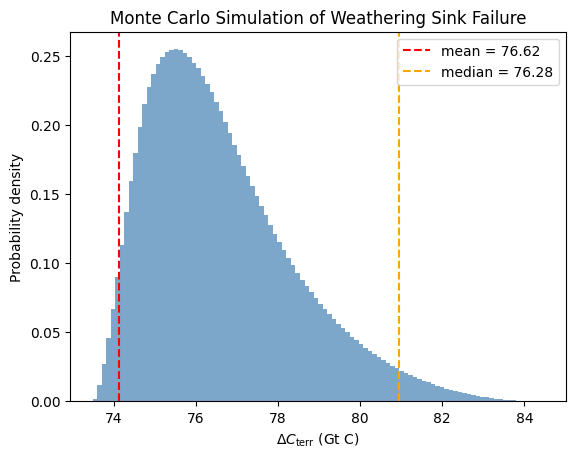

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# 固定参数
CIA_bg = 92.5
CIA_crisis = 82.0
CIA_min = 50
A = 31000  # km²
conv = 0.012  # kmol C -> t C
# 迭代次数
N = 10**8

# 参数分布
f = np.random.uniform(0.3, 0.7, N)
Fw = np.random.uniform(70, 200, N)  # kmol km⁻² yr⁻¹
dt = np.random.uniform(300, 900, N)  # kyr

# 计算 gamma
gamma = f * (CIA_bg - CIA_crisis) / (CIA_bg - CIA_min)

# 计算 Delta C_weathering (Gt C)
deltaC = Fw * conv * A * gamma * (dt * 1e3) * 1e-9 +72.9

# 统计
mean = np.mean(deltaC)
median = np.median(deltaC)
p2_5, p97_5 = np.percentile(deltaC, [2.5, 97.5])

print(f"均值: {mean:.2f} Gt C")
print(f"中位数: {median:.2f} Gt C")
print(f"95% 置信区间: [{p2_5:.2f}, {p97_5:.2f}] Gt C")

# 绘制分布图
plt.hist(deltaC, bins=100, density=True, alpha=0.7, color='steelblue')
plt.xlabel(r'$\Delta C_{\mathrm{terr}}$ (Gt C)')
plt.ylabel('Probability density')
plt.title('Monte Carlo Simulation of Weathering Sink Failure')
plt.axvline(p2_5, color='red', linestyle='--', label=f'mean = {mean:.2f}')
plt.axvline(p97_5, color='orange', linestyle='--', label=f'median = {median:.2f}')
plt.legend()
plt.show()

均值: 2.19 Gt C
中位数: 2.07 Gt C
95% 置信区间: [0.92, 4.03] Gt C


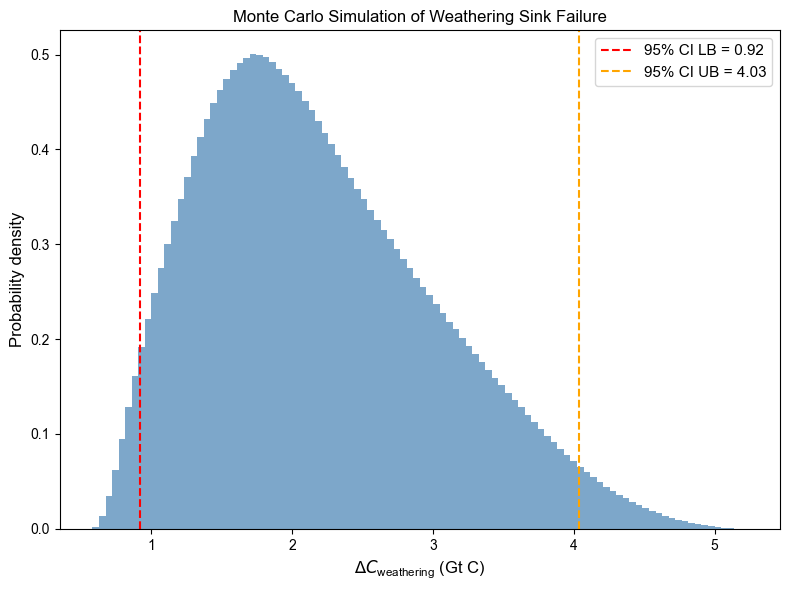

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ===================== 全局设置字体为 Arial =====================
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Arial'  # 数学公式也用Arial

# 固定参数
CIA_bg = 92.5
CIA_crisis = 82.0
CIA_min = 50
A = 31000  # km²
conv = 0.012  # kmol C -> t C
# 迭代次数
N = 10**8

# 参数分布
f = np.random.uniform(0.3, 0.7, N)
Fw = np.random.uniform(70, 200, N)  # kmol km⁻² yr⁻¹
dt = np.random.uniform(300, 407, N)  # kyr

# 计算 gamma
gamma = f * (CIA_bg - CIA_crisis) / (CIA_bg - CIA_min)

# 计算 Delta C_weathering (Gt C) + 截距 79.2
deltaC = Fw * conv * A * gamma * (dt * 1e3) * 1e-9

# 统计
mean = np.mean(deltaC)
median = np.median(deltaC)
p2_5, p97_5 = np.percentile(deltaC, [2.5, 97.5])

print(f"均值: {mean:.2f} Gt C")
print(f"中位数: {median:.2f} Gt C")
print(f"95% 置信区间: [{p2_5:.2f}, {p97_5:.2f}] Gt C")

# ===================== 绘图：拉长 + 标记原点 (79.2, 0) =====================
plt.figure(figsize=(8, 6))

plt.hist(deltaC, bins=100, density=True, alpha=0.7, color='steelblue')

# 标记 79.2
plt.annotate("79.2", xy=(79.2, 0), xytext=(79.2, -0.012),
             ha="center", fontsize=11, color="black")

# 坐标轴
plt.xlabel(r'$\Delta C_{\mathrm{weathering}}$ (Gt C)', fontsize=12)
plt.ylabel('Probability density', fontsize=12)
plt.title('Monte Carlo Simulation of Weathering Sink Failure')
# 置信区间线
plt.axvline(p2_5, color='red', linestyle='--', linewidth=1.5, label=f'95% CI LB = {p2_5:.2f}')
plt.axvline(p97_5, color='orange', linestyle='--', linewidth=1.5, label=f'95% CI UB = {p97_5:.2f}')

plt.legend(fontsize=11)
plt.tight_layout()

# ===================== 高清保存图片 =====================
plt.savefig("out_pic.png", dpi=300, bbox_inches="tight") # 保存为高清图

plt.show()

均值: 2.19 Gt C
中位数: 2.07 Gt C
95% 置信区间: [0.92, 4.03] Gt C


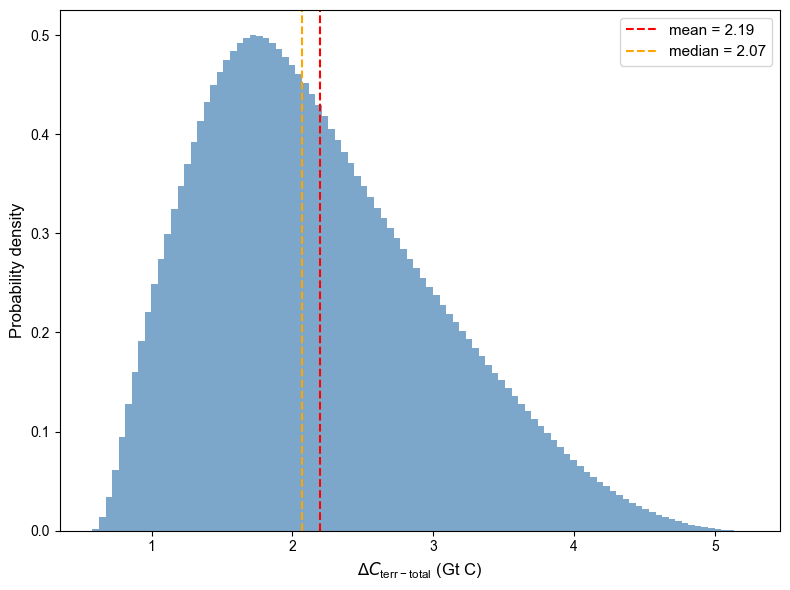

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ===================== 全局设置字体为 Arial =====================
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Arial'  # 数学公式也用Arial

# 固定参数
CIA_bg = 92.5
CIA_crisis = 82.0
CIA_min = 50
A = 31000  # km²
conv = 0.012  # kmol C -> t C
# 迭代次数
N = 10**8

# 参数分布
f = np.random.uniform(0.3, 0.7, N)
Fw = np.random.uniform(70, 200, N)  # kmol km⁻² yr⁻¹
dt = np.random.uniform(300, 407, N)  # kyr

# 计算 gamma
gamma = f * (CIA_bg - CIA_crisis) / (CIA_bg - CIA_min)

# 计算 Delta C_weathering (Gt C) + 截距 79.2
deltaC = Fw * conv * A * gamma * (dt * 1e3) * 1e-9

# 统计
mean = np.mean(deltaC)
median = np.median(deltaC)
p2_5, p97_5 = np.percentile(deltaC, [2.5, 97.5])

print(f"均值: {mean:.2f} Gt C")
print(f"中位数: {median:.2f} Gt C")
print(f"95% 置信区间: [{p2_5:.2f}, {p97_5:.2f}] Gt C")

# ===================== 绘图：拉长 + 标记原点 (79.2, 0) =====================
plt.figure(figsize=(8, 6))

plt.hist(deltaC, bins=100, density=True, alpha=0.7, color='steelblue')

# 标记 79.2
#plt.annotate("79.2", xy=(79.2, 0), xytext=(79.2, -0.012), ha="center", fontsize=11, color="black")

# 坐标轴
plt.xlabel(r'$\Delta C_{\mathrm{terr-total}}$ (Gt C)', fontsize=12)
plt.ylabel('Probability density', fontsize=12)

# 置信区间线
plt.axvline(mean, color='red', linestyle='--', linewidth=1.5, label=f'mean = {mean:.2f}')
plt.axvline(median, color='orange', linestyle='--', linewidth=1.5, label=f'median = {median:.2f}')

plt.legend(fontsize=11)
plt.tight_layout()

# ===================== 高清保存图片 =====================
plt.savefig("out_pic.png", dpi=300, bbox_inches="tight") # 保存为高清图

plt.show()

模拟次数: 100,000,000
ΔC_fire 均值: 717.37 Gt C
中位数: 433.35 Gt C
95% 置信区间: [233.02, 3085.08] Gt C


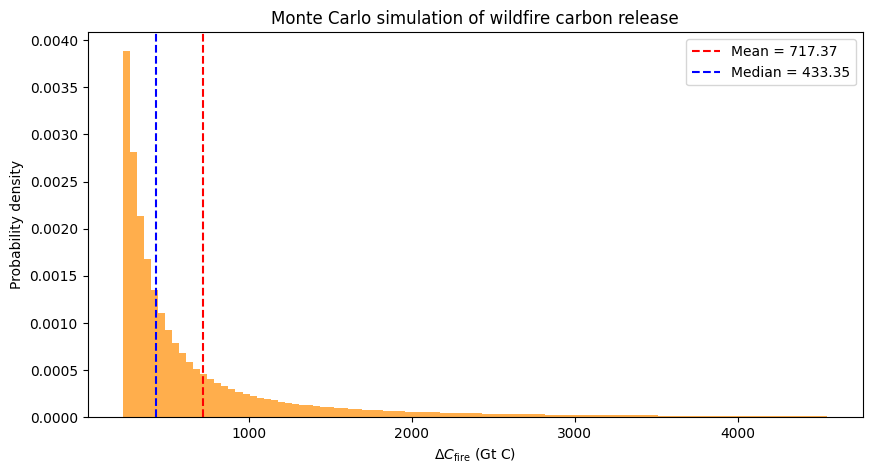

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# 设置随机种子
np.random.seed(42)

# 迭代次数
N = 10**8

# 1. 参数概率分布
# [Char] 假设为均匀分布，范围 8–14%（基于惰质组测量的不确定性）
Char = 0.112
alpha = np.random.uniform(0.001, 0.02, N)
rho = 2.6 * 1000

# 面积 A，均匀分布 25,000–37,000 km²（±20%）
A = 31000

# 事件持续时间 Δt 在计算中消去，但为了保持统一结构仍定义
# Δt 分布只用于 SAR，但 SAR = 28/Δt，最终 ΔC_fire 与 Δt 无关，因此可直接计算。

# 2. 计算 ΔC_fire (Gt C)
# 根据简化公式：ΔC_fire = (Char * 28 * rho * A) / alpha * 1e-6
# 注意单位：Char 无量纲，28 m，rho kg/m³，A km²，结果 Gt C
deltaC_fire = 0.018 * 1e-12 * (Char * 28 * rho * A * 1e6) / alpha

# 3. 统计结果
mean = np.mean(deltaC_fire)
median = np.median(deltaC_fire)
p2_5, p97_5 = np.percentile(deltaC_fire, [2.5, 97.5])

print(f"模拟次数: {N:,}")
print(f"ΔC_fire 均值: {mean:.2f} Gt C")
print(f"中位数: {median:.2f} Gt C")
print(f"95% 置信区间: [{p2_5:.2f}, {p97_5:.2f}] Gt C")

# 4. 绘制分布图
plt.figure(figsize=(10, 5))
plt.hist(deltaC_fire, bins=100, density=True, alpha=0.7, color='darkorange')
plt.axvline(mean, color='red', linestyle='--', label=f'Mean = {mean:.2f}')
plt.axvline(median, color='blue', linestyle='--', label=f'Median = {median:.2f}')
plt.xlabel(r'$\Delta C_{\mathrm{fire}}$ (Gt C)')
plt.ylabel('Probability density')
plt.title('Monte Carlo simulation of wildfire carbon release')
plt.legend()
plt.show()